<a href="https://colab.research.google.com/github/haujla2391/CSCI-4170/blob/main/02_RL_with_Q_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Checkpoint 2

# Q Learning EXTREME Super Genius Edition V1.0 (Taxi Pro++)

## Part A

We will implement tabular Q-learning on `Taxi-v3` environment, which mandates the agent to learn to navigate to the passenger, execute a "pickup" action, navigate to the destination, and execute a "dropoff" action. It tests the agent's ability to propagate sparse, delayed rewards over a longer sequence of specific, required actions.

In [ ]:
import gymnasium as gym
import numpy as np
import random

# Initialize the Taxi-v3 environment
env = gym.make("Taxi-v3")

# Inspect the action and state spaces
state_size = env.observation_space.n
action_size = env.action_space.n

print(f"Number of States: {state_size}")
print(f"Number of Actions: {action_size}")

Number of States: 500
Number of Actions: 6


In [ ]:
num_episodes = 100
total_rewards = []
total_steps = []

print(f"Random policy baseline for {num_episodes} episodes:")

for episode in range(num_episodes):
    state, info = env.reset()
    episode_reward = 0
    steps = 0
    done = False
    truncated = False

    # The environment loop
    while not (done or truncated):
        # Take a completely random action from the 6 possible actions
        action = env.action_space.sample()

        # Step the environment forward
        next_state, reward, done, truncated, info = env.step(action)

        episode_reward += reward
        steps += 1
    total_rewards.append(episode_reward)
    total_steps.append(steps)
env.close()

# Calculate the baseline metrics
avg_reward = np.mean(total_rewards)
avg_steps = np.mean(total_steps)

print("Random Baseline Results:")
print(f"Average Reward: {avg_reward:.2f}")
print(f"Average Steps:  {avg_steps:.2f}")

Random policy baseline for 100 episodes:
Random Baseline Results:
Average Reward: -756.67
Average Steps:  192.91


## Part B

In [ ]:
# Initialize Q-table
Q = np.zeros((state_size, action_size))

# Hyperparameters
alpha = 0.1        # learning rate
gamma = 0.99       # discount factor
epsilon = 1.0      # exploration rate
epsilon_min = 0.01
epsilon_decay = 0.999

num_episodes = 10000
max_steps = 100

# Track rewards
training_rewards = []

for episode in range(num_episodes):
    state, _ = env.reset()
    total_reward = 0

    for step in range(max_steps):
        # Epsilon-greedy action selection
        if random.uniform(0, 1) < epsilon:
            action = env.action_space.sample()  # explore
        else:
            action = np.argmax(Q[state])        # exploit

        next_state, reward, terminated, truncated, _ = env.step(action)

        # Q-learning update
        best_next_action = np.argmax(Q[next_state])
        Q[state, action] += alpha * (
            reward + gamma * Q[next_state, best_next_action] - Q[state, action]
        )

        state = next_state
        total_reward += reward

        if terminated or truncated:
            break

    # Decay epsilon
    epsilon = max(epsilon_min, epsilon * epsilon_decay)

    training_rewards.append(total_reward)

    # Optional progress print
    if (episode + 1) % 1000 == 0:
        avg_reward = np.mean(training_rewards[-1000:])
        print(f"Episode {episode+1}, Avg Reward: {avg_reward:.2f}, Epsilon: {epsilon:.3f}")

Episode 1000, Avg Reward: -251.22, Epsilon: 0.368
Episode 2000, Avg Reward: -33.55, Epsilon: 0.135
Episode 3000, Avg Reward: 2.72, Epsilon: 0.050
Episode 4000, Avg Reward: 6.28, Epsilon: 0.018
Episode 5000, Avg Reward: 7.29, Epsilon: 0.010
Episode 6000, Avg Reward: 7.41, Epsilon: 0.010
Episode 7000, Avg Reward: 7.37, Epsilon: 0.010
Episode 8000, Avg Reward: 7.24, Epsilon: 0.010
Episode 9000, Avg Reward: 7.48, Epsilon: 0.010
Episode 10000, Avg Reward: 7.34, Epsilon: 0.010


In [ ]:
num_eval_episodes = 100
eval_rewards = []

for episode in range(num_eval_episodes):
    state, _ = env.reset()
    total_reward = 0

    for step in range(max_steps):
        # Pure greedy policy
        action = np.argmax(Q[state])

        next_state, reward, terminated, truncated, _ = env.step(action)

        state = next_state
        total_reward += reward

        if terminated or truncated:
            break

    eval_rewards.append(total_reward)

print(f"\nAverage Evaluation Reward over {num_eval_episodes} episodes: {np.mean(eval_rewards):.2f}")


Average Evaluation Reward over 100 episodes: 8.46


## Part C

In [ ]:
def train_q_learning(env, episodes, alpha, gamma, epsilon, epsilon_decay=None, epsilon_min=0.01):
    Q = np.zeros((env.observation_space.n, env.action_space.n))
    rewards = []

    for ep in range(episodes):
        state, _ = env.reset()
        total_reward = 0

        for _ in range(100):
            # Epsilon-greedy
            if random.uniform(0, 1) < epsilon:
                action = env.action_space.sample()
            else:
                action = np.argmax(Q[state])

            next_state, reward, terminated, truncated, _ = env.step(action)

            # Q update
            Q[state, action] += alpha * (
                reward + gamma * np.max(Q[next_state]) - Q[state, action]
            )

            state = next_state
            total_reward += reward

            if terminated or truncated:
                break

        rewards.append(total_reward)

        # Decay epsilon if enabled
        if epsilon_decay is not None:
            epsilon = max(epsilon_min, epsilon * epsilon_decay)

    return Q, rewards

def evaluate_policy(env, Q, episodes=100):
    rewards = []
    successes = 0

    for _ in range(episodes):
        state, _ = env.reset()
        total_reward = 0

        for _ in range(100):
            action = np.argmax(Q[state])
            next_state, reward, terminated, truncated, _ = env.step(action)

            state = next_state
            total_reward += reward

            if terminated or truncated:
                if reward == 20:  # successful drop-off in Taxi
                    successes += 1
                break

        rewards.append(total_reward)

    avg_reward = np.mean(rewards)
    success_rate = successes / episodes

    return avg_reward, success_rate

def random_policy(env, episodes=100):
    rewards = []
    successes = 0

    for _ in range(episodes):
        state, _ = env.reset()
        total_reward = 0

        for _ in range(100):
            action = env.action_space.sample()
            state, reward, terminated, truncated, _ = env.step(action)

            total_reward += reward

            if terminated or truncated:
                if reward == 20:
                    successes += 1
                break

        rewards.append(total_reward)

    return np.mean(rewards), successes / episodes

Fixed ε Avg (last 100): 2.81
Decay ε Avg (last 100): 7.33

--- Evaluation ---
Random: Avg Reward=-392.03, Success=0.01
Fixed ε: Avg Reward=8.05, Success=1.00
Decay ε: Avg Reward=8.02, Success=1.00


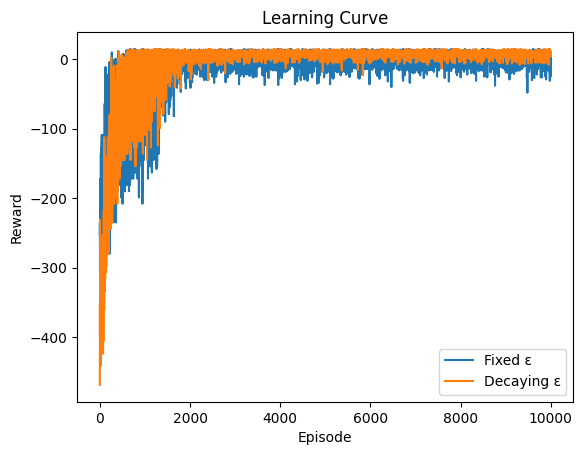

In [ ]:
episodes = 10000

# Variant 1: Fixed epsilon
Q_fixed, rewards_fixed = train_q_learning(
    env, episodes, alpha=0.1, gamma=0.99,
    epsilon=0.1, epsilon_decay=None
)

# Variant 2: Decaying epsilon
Q_decay, rewards_decay = train_q_learning(
    env, episodes, alpha=0.1, gamma=0.99,
    epsilon=1.0, epsilon_decay=0.995
)

# Random baseline
rand_avg, rand_success = random_policy(env)

# Evaluate learned policies
fixed_avg, fixed_success = evaluate_policy(env, Q_fixed)
decay_avg, decay_success = evaluate_policy(env, Q_decay)

print("Fixed ε Avg (last 100):", np.mean(rewards_fixed[-100:]))
print("Decay ε Avg (last 100):", np.mean(rewards_decay[-100:]))

print("\n--- Evaluation ---")
print(f"Random: Avg Reward={rand_avg:.2f}, Success={rand_success:.2f}")
print(f"Fixed ε: Avg Reward={fixed_avg:.2f}, Success={fixed_success:.2f}")
print(f"Decay ε: Avg Reward={decay_avg:.2f}, Success={decay_success:.2f}")

import matplotlib.pyplot as plt

plt.plot(rewards_fixed, label="Fixed ε")
plt.plot(rewards_decay, label="Decaying ε")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Learning Curve")
plt.legend()
plt.show()

In [ ]:
policy = np.argmax(Q_decay, axis=1)
print(policy.reshape(25, 20))  # rough structure

action_map = {
    0: "↓",  # south
    1: "↑",  # north
    2: "→",  # east
    3: "←",  # west
    4: "P",  # pickup
    5: "D"   # dropoff
}

policy_symbols = [action_map[a] for a in policy]
print(np.array(policy_symbols).reshape(25, 20))

[[0 4 4 4 0 0 0 0 0 0 0 0 2 0 0 0 5 0 0 0]
 [0 3 3 3 0 0 0 0 0 3 0 0 0 0 0 0 3 0 0 0]
 [0 0 0 0 2 0 2 2 0 0 0 0 0 2 2 0 0 2 0 1]
 [0 0 0 3 2 0 2 2 0 0 0 0 0 0 0 0 0 2 0 0]
 [0 0 0 3 4 0 4 4 3 0 0 0 3 3 0 0 0 5 3 0]
 [0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0]
 [0 3 3 3 0 0 0 0 0 0 0 0 0 0 0 0 3 0 3 0]
 [0 0 0 0 2 0 2 2 0 0 0 0 0 0 0 0 0 2 0 2]
 [0 0 0 0 2 0 1 1 3 0 0 0 0 0 0 0 3 2 0 0]
 [0 0 0 0 1 0 1 1 3 3 0 3 3 3 3 0 0 1 3 3]
 [0 1 1 1 2 0 2 2 0 0 0 0 2 2 2 0 1 2 0 2]
 [0 1 1 3 2 0 2 2 3 3 0 3 2 2 2 0 3 2 3 2]
 [0 3 3 3 2 0 1 2 3 3 0 3 2 2 2 0 3 1 3 2]
 [0 3 3 3 1 0 1 1 3 3 0 3 0 0 0 0 3 1 3 0]
 [0 3 3 3 1 0 1 1 3 3 0 3 0 0 3 0 3 1 3 1]
 [0 1 1 1 1 0 1 1 0 0 0 0 1 1 1 0 1 1 0 1]
 [0 1 1 1 1 0 2 2 1 1 0 1 1 2 2 0 1 1 1 1]
 [0 1 1 1 1 0 1 1 1 1 0 3 1 1 1 0 1 1 3 1]
 [0 1 1 1 1 0 1 1 1 1 0 1 0 0 0 0 1 1 1 0]
 [0 3 3 1 1 0 1 1 1 1 0 3 3 3 3 0 1 1 1 3]
 [0 1 1 1 1 0 1 1 4 4 0 4 1 1 1 0 1 1 5 1]
 [0 1 1 1 1 0 1 2 1 1 0 1 1 1 2 0 0 2 0 3]
 [0 1 1 1 1 0 1 1 3 1 0 1 1 1 1 0 0 0 0 0]
 [0 1 1 1 1

## Part D

In the Taxi environment, the primary goal (+20 reward) is hidden at the very end of a specific sequence of actions (navigate to pickup to navigate to dropoff).

Without Exploration (Pure Exploitation): If $\epsilon$ was set to 0, the agent would rely entirely on its initialized Q-table (all zeros). It would take an action, receive a -1 penalty, and that state-action pair would become negative. The agent would then just pick any other "zero" action, effectively spinning in circles or getting stuck against a wall to avoid the actions it knows yield a -1. It would never accidentally stumble upon the +20 dropoff reward.

With Fixed High Exploration: If $\epsilon$ was locked at a high value (such as 0.5), the agent would learn the optimal path eventually, but its evaluation performance would be terrible. Even if the Q-table knew the perfect route, the agent would randomly veer off course 50% of the time, making illegal pickups (-10) and wasting time (-1).

With Ideal Decay: By starting $\epsilon$ at 1.0 and decaying it, the agent acts entirely randomly at first—which is exactly what is needed to stumble upon the delayed +20 reward. Once that reward is found, the decaying $\epsilon$ allows the agent to gradually stop exploring and start trusting the optimal path it has built.

A Failure Mode: Premature Epsilon Decay

If $\epsilon$ decay rate is set too aggressively (e.g. multiplying by 0.5 every episode instead of 0.999). Epsilon would drop to near-zero before the agent ever successfully drops off a passenger. Since the agent only experienced the -1 step penalties and -10 illegal action penalties, all updated Q-values are negative.

The agent becomes "afraid" of every action it has tried. It will find a state where taking a specific action (like moving North into a wall) hasn't been heavily penalized yet, or it will just alternate between moving North and South forever. It converges perfectly, but it converges on a fundamentally broken, useless policy because it stopped looking for the goal too early.

How Alpha, Gamma, and Epsilon Interact:

* Epsilon ($\epsilon$) is the discoverer in that it forces the agent to take random actions to eventually find the sparse +20 dropoff reward.
* Gamma ($\gamma$) is the messenger in that once $\epsilon$ finds the +20 reward, $\gamma$ (the discount factor) dictates how strongly that reward is passed backward to previous states. A high $\gamma$ (0.99) tells the agent, "Taking a -1 penalty right now is worth it because it leads to a +20 reward five steps from now." If $\gamma$ was 0, the agent would be completely myopic, only trying to avoid the immediate -1 step penalties, and would never string together the pickup/dropoff sequence.
* Alpha ($\alpha$) is the memory in that once $\epsilon$ finds the goal and $\gamma$ passes the value backward, $\alpha$ (the learning rate) decides how quickly to overwrite the old Q-values with this new information. If $\alpha$ is too low, the agent requires thousands of successful dropoffs to solidify the path.
